# Home Credit Default Risk

The goal of this notebook is to build a model that estimates the probability of client default for a credit application. The main dataset is `application_train`, while additional Home Credit tables (`bureau`, `bureau_balance`, `credit_card_balance`, `installments_payments`, `POS_CASH_balance`, `previous_application`) are aggregated to the client level and added as features.

The notebook follows a full machine learning pipeline:

1. load and merge the data;
2. explore the target and feature distributions;
3. handle missing values and create additional features;
4. train several baseline models;
5. compare model quality with ROC-AUC and PR-AUC;
6. select features using LightGBM feature importance;
7. tune hyperparameters with Optuna;
8. train the final model and create `submission.csv`.

Because the target is highly imbalanced, PR-AUC / Average Precision is especially important. It evaluates how well the model identifies the rare positive class, where `TARGET = 1` means a client had payment difficulties.


## Imports and Project Functions

This cell imports the main libraries for data processing, visualization, and machine learning. It also imports helper functions from the local `src` package. These project functions load the CSV files and build aggregated features from the additional Home Credit tables.


In [ ]:
import warnings
import lightgbm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from src.data_loader import load_core_tables
from src.features import merge_bureau_features, merge_bureau_balance_features, merge_credit_credit_features, \
    merge_installments_payments_features
from src.features import merge_POS_CASH_BALANCE_features
from src.features import merge_previous_application_features

warnings.filterwarnings("ignore")


## Loading and Merging Data Sources

The core tables are loaded first. Then the train and test datasets are enriched with client-level features from several external sources:

- credit bureau history from `bureau`;
- monthly bureau status history from `bureau_balance`;
- credit card behavior from `credit_card_balance`;
- installment payment history from `installments_payments`;
- POS/CASH loan history from `POS_CASH_balance`;
- previous applications from `previous_application`.

All aggregated features are merged by `SK_ID_CURR`, so each row still represents one client application.


In [ ]:
tables = load_core_tables('.')

train = merge_bureau_features(tables['application_train'], tables['bureau'])
test = merge_bureau_features(tables['application_test'], tables['bureau'])

train = merge_bureau_balance_features(train, tables['bureau'], tables['bureau_balance'])
test = merge_bureau_balance_features(test, tables['bureau'], tables['bureau_balance'])

train = merge_credit_credit_features(train, tables['credit_card_balance'])
test = merge_credit_credit_features(test, tables['credit_card_balance'])

train = merge_installments_payments_features(train, tables['installments_payments'])
test = merge_installments_payments_features(test, tables['installments_payments'])

train = merge_POS_CASH_BALANCE_features(train, tables['POS_CASH_balance'])
test = merge_POS_CASH_BALANCE_features(test, tables['POS_CASH_balance'])

train = merge_previous_application_features(train, tables['previous_application'])
test = merge_previous_application_features(test, tables['previous_application'])

## Dataset Shapes

After merging the additional features, I check the shape of the train and test datasets. This is a quick sanity check that the feature joins worked correctly and did not change the number of applications.


In [ ]:
print(f'Размер тренировочной выборки:{train.shape}')
print(f'Размер тренировочной выборки:{test.shape}')

## Exploratory Data Analysis

This section starts with the distribution of the target variable. The default class is much smaller than the non-default class, so the task is imbalanced and accuracy alone would not be a reliable metric.

Then I compare the default rate across several categorical variables and inspect the distributions of important numerical features. This helps identify risk patterns, outliers, and variables that may be useful for the model.


In [ ]:
target_counts = train['TARGET'].value_counts()
import seaborn as sns

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title('Distribution of TARGET')
plt.xlabel('TARGET')
plt.ylabel('Count')
plt.grid()
plt.show()

plt.figure(figsize=(6, 4))
cols = [
    "CODE_GENDER",
    "NAME_CONTRACT_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS"
]
color = ['r', 'b', 'g', 'y', 'm', 'w']
i = 0
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()
for j, col in enumerate(cols):
    rate = (train.groupby(col)["TARGET"].mean() * 100).sort_values(ascending=False)
    color_current = color[i]
    axes[j].bar(rate.index, rate.values, color=color_current)
    axes[j].set_title(f"Частота TARGET=1 по {col}")
    axes[j].set_ylabel("TARGET=1, %")
    axes[j].set_xlabel("")
    axes[j].tick_params(axis="x", rotation=45)
    axes[j].grid()
    i += 1
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
col_money = ['AMT_INCOME_TOTAL',
             'AMT_CREDIT',
             'AMT_ANNUITY',
             'DAYS_BIRTH',
             'DAYS_EMPLOYED']
axes = axes.flatten()
for j, col in enumerate(col_money):
    values = train[col]
    color_current = color[j]
    axes[j].hist(values, bins=30, color=color_current, edgecolor="black")
    axes[j].set_title(f"Распределение {col}")
    axes[j].set_ylabel("Количество")
    axes[j].set_xlabel(col)
    axes[j].tick_params(axis="x", rotation=45)
    axes[j].grid()
plt.tight_layout()
fig.delaxes(axes[5])
plt.show()

## Credit Amount by Target Class

This plot compares the distribution of `AMT_CREDIT` for clients with `TARGET = 0` and `TARGET = 1`. The distributions are normalized with `density=True`, which makes the shapes comparable even though the two classes have very different sizes.


In [ ]:
plt.figure(figsize=(10, 10))
plt.hist(train[train['TARGET'] == 1]['AMT_CREDIT'], bins=30, alpha=0.5, label='TARGET 1', density=True)
plt.hist(train[train['TARGET'] == 0]['AMT_CREDIT'], bins=30, alpha=0.5, label='TARGET 0', density=True)
plt.title("AMT_CREDIT по TARGET")
plt.xlabel("AMT_CREDIT")
plt.ylabel("Количество")
plt.legend()
plt.grid(True)
plt.show()

## Default Rate by Credit Amount

The credit amount is split into quantile bins, and the default rate is calculated for each bin. This makes it easier to see whether the probability of default changes as the requested credit amount increases.


In [ ]:
credit_bins = pd.qcut(train["AMT_CREDIT"], q=5)
rate = train.groupby(credit_bins)["TARGET"].mean() * 100
plt.figure(figsize=(10, 10))
plt.plot(rate.index.astype(str), rate.values, marker="o")
plt.title("Доля TARGET=1 по  AMT_CREDIT")
plt.xlabel("AMT_CREDIT")
plt.ylabel("TARGET=1, %")
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Income, Employment, and Age

The value `365243` in `DAYS_EMPLOYED` is replaced with a missing value because it is a special code in this dataset, not a real employment duration. Then I visualize the log-transformed income and the client's age in years. The log transformation makes the strongly skewed income distribution easier to read.


In [ ]:
train["DAYS_EMPLOYED"] = train["DAYS_EMPLOYED"].replace(365243, np.nan)
plt.figure(figsize=(6, 4))
plt.hist(np.log1p(train["AMT_INCOME_TOTAL"].dropna()), bins=30)
plt.title("Распределение log(AMT_INCOME_TOTAL)")
plt.xlabel("log(AMT_INCOME_TOTAL)")
plt.ylabel("Количество")
plt.grid(alpha=0.3)
plt.show()
train['age_years'] = -train["DAYS_BIRTH"] / 365

plt.figure(figsize=(6, 4))
plt.hist(train['age_years'].dropna(), bins=30, color="gold")
plt.title("Распределение возраста")
plt.xlabel("Возраст, лет")
plt.ylabel("Количество")
plt.grid(alpha=0.3)
plt.show()

## From EDA to Data Preparation

After the initial analysis, the dataset clearly contains missing values, special placeholder values, categorical variables, and numerical features on very different scales. Before model training, these issues need to be converted into a stable modeling format.


## Missing Values and Feature Engineering

The `FEATURE_ENGINEERING` function prepares the data for modeling. The main steps are:

- fill missing numerical values with means, medians, zeros, or special values;
- replace missing categorical values with `Unknown`;
- add binary indicators for available POS history, previous application history, and approved previous applications;
- create indicators based on credit bureau request variables;
- create ratio features such as `credit_income_credit`, `annuity_to_income`, and `income_for_person`;
- aggregate `EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3` with mean, max, min, and standard deviation;
- replace infinite values and remaining missing values at the end.

The purpose of this step is to produce a stable feature matrix that can be safely passed to machine learning models.


In [ ]:
def FEATURE_ENGINEERING(dataset: pd.DataFrame) -> pd.DataFrame:
    train = dataset.copy()
    few_passes = ['DAYS_LAST_PHONE_CHANGE',
                  'CNT_FAM_MEMBERS',
                  'AMT_ANNUITY',
                  'AMT_GOODS_PRICE']
    train[few_passes] = train[few_passes].fillna(train[few_passes].mean())
    social_columns = ['OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
                      'DEF_60_CNT_SOCIAL_CIRCLE']
    train[social_columns] = train[social_columns].fillna(0)
    amt_req = [col for col in train.columns if col.startswith('AMT_REQ_CREDIT_BUREAU')]
    for i in range(len(amt_req)):
        train[f'have_checked_req_credit_{i}'] = (train[amt_req[i]] > 0).astype(int)
    train[amt_req] = train[amt_req].fillna(0)
    ext_sour = [col for col in train.columns if col.startswith('EXT_SOURCE_')]
    for ext in ext_sour:
        train[ext] = train[ext].fillna(train[ext].mean())
    past_end = [col for col in train.columns if col.startswith('PAST_END')]
    early_close = [col for col in train.columns if col.startswith('EARLY_CLOSE')]
    ins_col = [col for col in train.columns if col.startswith('INS')]
    pos_col = [col for col in train.columns if col.startswith('POS')]
    approv_col = [col for col in train.columns if col.startswith('APPROVED')]
    prev_col = [col for col in train.columns if col.startswith('PREV')]
    train[pos_col] = train[pos_col].fillna(0)
    train[approv_col] = train[approv_col].fillna(0)
    train[prev_col] = train[prev_col].fillna(0)
    train[ins_col] = train[ins_col].fillna(0)
    credit_cols = [
        'CREDIT_COUNT', 'CREDIT_MEAN', 'CREDIT_MAX',
        'ACTIVE_CREDIT_SUM', 'ACTIVE_CREDIT_MEAN',
        'CREDIT_DAY_OVERDUE_SUM', 'CREDIT_DAY_OVERDUE_MAX',
        'CREDIT_DAY_OVERDUE_MIN', 'CREDIT_DAY_OVERDUE_MEAN',
        'DAYS_CREDIT_ENDDATE_MIN', 'DAYS_CREDIT_ENDDATE_MAX',
        'DAYS_CREDIT_ENDDATE_MEAN', 'DAYS_ENDDATE_FACT_MEAN'
    ]
    bureau_features = [
        'CREDIT_SUM',
        'DAYS_CREDIT_MOST_RECENT',
        'DAYS_CREDIT_MEAN',
        'DAYS_CREDIT_OLDEST',
        'DAYS_CREDIT_ENDDATE_SUM'
    ]
    train['OWN_CAR_AGE'] = train['OWN_CAR_AGE'].fillna(0)
    train[credit_cols] = train[credit_cols].fillna(0)
    train[bureau_features] = train[bureau_features].fillna(0)
    for past in past_end:
        train[past] = train[past].fillna(0)
    for early in early_close:
        train[early] = train[early].fillna(0)
    categorical = [
        'NAME_TYPE_SUITE',
        'OCCUPATION_TYPE',
        'EMERGENCYSTATE_MODE',
        'HOUSETYPE_MODE',
        'WALLSMATERIAL_MODE',
        'FONDKAPREMONT_MODE'
    ]
    loan_types = [
        'Another type of loan',
        'Car loan',
        'Loan for business development',
        'Consumer credit',
        'Credit card',
        'Interbank credit',
        'Loan for the purchase of equipment',
        'Loan for purchase of shares (margin lending)',
        'Loan for working capital replenishment',
        'Cash loan (non-earmarked)',
        'Real estate loan',
        'Mortgage',
        'Mobile operator loan',
        'Unknown type of loan',
        'Microloan'
    ]
    train['HAS_POS_HISTORY'] = train['POS_PREV_CREDIT_COUNT'].notna().astype(int)
    train['HAS_PREV_HISTORY'] = train['PREV_APPLICATION_COUNT'].notna().astype(int)
    train['HAS_APPROVED_HISTORY'] = train['APPROVED_AMT_CREDIT_MEAN'].notna().astype(int)

    housing = [
        'TOTALAREA_MODE',

        'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_MODE',
        'YEARS_BUILD_AVG', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE',

        'FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE',
        'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE',

        'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE',
        'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE',

        'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE',
        'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE',
        'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE',

        'BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_MODE',
        'COMMONAREA_AVG', 'COMMONAREA_MEDI', 'COMMONAREA_MODE',
        'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE',

        'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'ENTRANCES_MODE',
        'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE'
    ]
    train[categorical] = train[categorical].fillna('Unknown')
    train[loan_types] = train[loan_types].fillna(0)
    train[housing] = train[housing].fillna(-1)
    bb_cols = [col for col in train.columns if col.startswith("BB_")]
    train[bb_cols] = train[bb_cols].fillna(0)
    train[bb_cols] = train[bb_cols].fillna(0)
    credit_card_cols = [
        "balance_to_limit_mean",
        "balance_to_limit_max",
        "dpd_mean",
        "dpd_max",
        "payment_to_min_mean",
        "payment_to_min_max",
        "payment_to_balance_mean",
        "payment_to_balance_max",
        "drawings_to_limit_mean",
        "drawings_to_limit_max",
    ]

    train[credit_card_cols] = train[credit_card_cols].fillna(0)
    train["DAYS_EMPLOYED"] = train["DAYS_EMPLOYED"].fillna(train["DAYS_EMPLOYED"].median())
    train = train.copy()
    train['credit_income_credit'] = train['AMT_CREDIT'] / train[
        'AMT_INCOME_TOTAL']
    train['annuity_to_income'] = train['AMT_ANNUITY'] / train[
        'AMT_INCOME_TOTAL']
    train['income_for_person'] = train['AMT_INCOME_TOTAL'] / train[
        'CNT_FAM_MEMBERS']
    train['EXT_SOURCE_MEAN'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    train['EXT_SOURCE_MAX'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].max(axis=1)
    train['EXT_SOURCE_MIN'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)
    train['EXT_SOURCE_STD'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)
    train.isnull().sum().sort_values(ascending=False).head(30)
    train = train.replace([np.inf, -np.inf], np.nan).fillna(0)
    return train


## Preparing Model Inputs

The next step is to separate `TARGET`, split the data into training and validation parts, and prepare two feature representations: One-Hot Encoded features for most models and original categorical features for CatBoost.


## Train/Test Split and Encoding

The `get_train_test_data` function separates the target variable, performs a stratified train/test split, and applies One-Hot Encoding to categorical features.

Separate datasets are kept for CatBoost because CatBoost can handle categorical features directly. The other models use the One-Hot Encoded feature matrix.


In [ ]:
def get_train_test_data(train: pd.DataFrame):
    Y = train['TARGET']
    X = train.drop('TARGET', axis=1)
    cat_cols = X.select_dtypes(include=['object']).columns

    x_train, x_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42, stratify=Y
    )
    x_train_for_catboost = x_train
    x_test_for_catboost = x_test
    y_train_for_catboost = y_train
    y_test_for_catboost = y_test
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    x_train_ohe = ohe.fit_transform(x_train[cat_cols])
    x_train_ohe_df = pd.DataFrame(x_train_ohe, columns=ohe.get_feature_names_out(cat_cols), index=x_train.index)
    x_test_ohe = ohe.transform(x_test[cat_cols])
    x_test_ohe_df = pd.DataFrame(
        x_test_ohe,
        columns=ohe.get_feature_names_out(cat_cols),
        index=x_test.index
    )

    x_train = x_train.drop(columns=cat_cols)
    x_test = x_test.drop(columns=cat_cols)

    x_train = pd.concat([x_train, x_train_ohe_df], axis=1)
    x_test = pd.concat([x_test, x_test_ohe_df], axis=1)
    print(x_train.shape, x_test.shape)
    return x_train, x_test, y_train, y_test, x_train_for_catboost, x_test_for_catboost, y_train_for_catboost, y_test_for_catboost


## Baseline Model Setup

Four baseline models are compared:

- `LogisticRegression` as a simple linear model;
- `RandomForest` as a tree ensemble;
- `LightGBM` as a gradient boosting model;
- `CatBoost` as a boosting model with native categorical feature support.

Logistic regression is trained on scaled features, while tree-based models can work with the original feature scale. After defining the models, feature engineering is applied and the train/test matrices are prepared.


In [ ]:
models = {
    "LogisticRegression": {
        "model": LogisticRegression(
            random_state=42,
            max_iter=1000
        ),
        "scaled": True,
    },

    "RandomForest": {
        "model": RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1,
            verbose=0
        ),
        "scaled": False,
    },

    "LightGBM": {
        "model": LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=-1
        ),
        "scaled": False,
    },

    "CatBoost": {
        "model": CatBoostClassifier(
            iterations=500,
            learning_rate=0.03,
            depth=6,
            eval_metric="PRAUC",
            random_seed=42,
            verbose=False
        ),
        "scaled": False,
    },
}
train = FEATURE_ENGINEERING(train)
train_for_learning_before_test = train.copy()
test = FEATURE_ENGINEERING(test)
x_train, x_test, y_train, y_test, x_train_for_catboost, x_test_for_catboost, y_train_for_catboost, y_test_for_catboost = get_train_test_data(
    train)
x_train_copy = x_train.copy()

## Baseline Training and Evaluation

Each model is trained on the training split and evaluated on the validation split. The models produce default probabilities, which are used to calculate ROC-AUC and PR-AUC and to draw ROC and Precision-Recall curves.


In [ ]:
results_baseline = {}
cat_cols = train.drop(columns=['TARGET']).select_dtypes(include=['object']).columns

for name, info in models.items():
    print(f'Сейчас обучаем {name}')
    model = info['model']
    if name == "CatBoost":
        model.fit(x_train_for_catboost, y_train_for_catboost, cat_features=cat_cols.to_list())
        y_proba = model.predict_proba(x_test_for_catboost)[:, 1]
        y_pred = model.predict(x_test_for_catboost)
        x_train_for_catboost = x_train

    else:
        if info['scaled']:
            scaler = StandardScaler()
            x_train = scaler.fit_transform(x_train)
            x_test = scaler.transform(x_test)
            x_train_for_not_catboost = x_train
            x_test_for_not_catboost = x_test

        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        y_proba = model.predict_proba(x_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_proba)
    fpr, tpr, threshold_roc = roc_curve(y_test, y_proba)
    accuracy = accuracy_score(y_test, y_pred)
    results_baseline[name] = {
        "model": model,
        "accuracy": accuracy,
        "precisions": precisions,
        "recalls": recalls,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "fpr": fpr,
        "tpr": tpr,
        "threshold_roc": threshold_roc,
        "thresholds_pr": thresholds_pr
    }

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.show()


## Comparing Baseline Metrics

The baseline metrics are collected and visualized together. ROC-AUC measures the general ranking quality of the model, while PR-AUC is more informative for the rare default class.


In [ ]:
model_names = list(results_baseline.keys())
pr_aucs = [results_baseline[name]["pr_auc"] for name in model_names]
roc_aucs = [results_baseline[name]["roc_auc"] for name in model_names]

plt.figure(figsize=(8, 6))
plt.bar(model_names, pr_aucs)
plt.title("PR-AUC by Model")
plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.bar(model_names, roc_aucs)
plt.title("ROC-AUC by Model")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.grid(True)
plt.show()

## Comparing ROC and Precision-Recall Curves

Plotting all curves together shows how the models behave across different classification thresholds. This is useful in credit scoring because the decision threshold can be adjusted depending on the business objective.


In [ ]:
for name, metrics in results_baseline.items():
    plt.plot(metrics["fpr"], metrics["tpr"], label=f"{name}: {metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()
for name, metrics in results_baseline.items():
    plt.plot(metrics["recalls"], metrics['precisions'], label=f"{name}: {metrics['pr_auc']:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

## LightGBM Feature Importance

After baseline training, I use the LightGBM feature importances to identify which variables contribute most to the model. This also prepares the next step: selecting a smaller set of the most useful features.


In [ ]:
feature_importance = pd.DataFrame({
    'feature': x_train_copy.columns,
    'importance': models['LightGBM']['model'].feature_importances_
}).sort_values('importance', ascending=False)

top_features = feature_importance.head(50).sort_values('importance', ascending=False)
plt.figure(figsize=(15, 15))
plt.barh(top_features['feature'], top_features['importance'])
plt.title('Top 50 LightGBM Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Converting Arrays Back to DataFrames

After scaling, the non-CatBoost feature matrices are numpy arrays. They are converted back to `DataFrame` objects so that column names are preserved and top features can be selected by name.


In [ ]:
x_train_for_not_catboost_df = pd.DataFrame(
    x_train_for_not_catboost,
    columns=x_train_copy.columns
)
x_test_for_not_catboost_df = pd.DataFrame(
    x_test_for_not_catboost,
    columns=x_train_copy.columns
)

## Cleaning Column Names

The One-Hot Encoded column names are cleaned by replacing special characters. This reduces the risk of issues in LightGBM and makes it easier to align train and test columns later.


In [ ]:
import re

clean_columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in x_train_for_not_catboost_df.columns
]
x_train_for_not_catboost_df.columns = clean_columns
x_test_for_not_catboost_df.columns = clean_columns
feature_importance['feature'] = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in feature_importance['feature']
]

## Feature Count Experiment

This experiment checks how LightGBM performance changes when using different numbers of the most important features. For each value of `n_features`, a new model is trained and evaluated with ROC-AUC and PR-AUC.


In [ ]:
results = []

feature_counts = [1, 2, 10, 15, 20, 30, 50, 80, 120, 150, 200, 250, 300, 350, 382]

for n in feature_counts:
    top_n_features = feature_importance.head(n)['feature'].tolist()

    x_train_top = x_train_for_not_catboost_df[top_n_features]
    x_test_top = x_test_for_not_catboost_df[top_n_features]

    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )

    model.fit(x_train_top, y_train)
    y_proba = model.predict_proba(x_test_top)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    results.append({
        'n_features': n,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    })

## Feature Selection Results

The results are collected in `results_df`. The saved table shows that performance grows quickly during the first groups of features, while the improvement becomes small after roughly 150-200 features. Because of that, the next steps use a compact set of the top 150 features.


In [ ]:

results_df = pd.DataFrame(results)
results_df

## Performance vs. Number of Features

This plot helps choose a balance between model quality and model complexity. If adding more features gives almost no improvement in ROC-AUC or PR-AUC, a smaller feature set is preferable.


In [ ]:
results_plot = results_df.copy()
results_plot['n_features'] = results_plot['n_features'].astype(str)

plt.figure(figsize=(8, 5))
plt.plot(results_plot['n_features'], results_plot['roc_auc'], marker='o', label='ROC-AUC')
plt.plot(results_plot['n_features'], results_plot['pr_auc'], marker='o', label='PR-AUC')
plt.title('LightGBM Performance vs Number of Features')
plt.xlabel('Number of Features')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()




## Final Feature Set

The variable `final_features` stores the top 150 features according to LightGBM importance. This feature list is used for hyperparameter tuning and for the final model.


In [ ]:
final_features = feature_importance.head(150)['feature'].tolist()

## Hyperparameter Tuning with Optuna

LightGBM hyperparameters are tuned with Optuna. The optimization target is `average_precision`, which corresponds to PR-AUC and is suitable for this imbalanced classification problem.

Optuna tries different parameter combinations, keeps the best configuration, and then trains a model with the selected parameters. The tuned model is evaluated on the validation split and with cross-validation using Average Precision.


In [ ]:
import time
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 100
TIMEOUT = 4000

optimization_functions = {
    'LightGBM': optimize_LightGBM_with_optuna,
}

x_train_for_not_catboost_df_opt = x_train_for_not_catboost_df[final_features]
optimized_results = {}
optimization_studies = {}
optimization_times = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def print_optuna_progress(study, trial):
    if study.best_trial.number == trial.number:
        print(
            f"[Optuna] Новый лучший trial #{trial.number} | "
            f"average_precision = {trial.value:.5f}"
        )


start_total_time = time.time()

for model_name, func in optimization_functions.items():
    print(f"Начинаем Оптимизацию {model_name}")

    start_time = time.time()

    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=42)
    )

    study.optimize(
        lambda trial: func(trial, x_train_for_not_catboost_df_opt, y_train),
        n_trials=N_TRIALS,
        timeout=TIMEOUT,
        show_progress_bar=False,
    )

    end_time = time.time()
    optimization_time = end_time - start_time
    optimization_times[model_name] = optimization_time
    optimization_studies[model_name] = study

    best_params = study.best_params
    best_score = study.best_value

    print(f"\nОптимизация {model_name} успешно завершена")
    print(f"Завершено за {optimization_time:.1f} секунд")
    print(f"Лучший average_precision: {best_score:.5f}")
    print(f"Проведено {len(study.trials)} попыток")
    print("Лучшие параметры:")
    for param_name, param_value in best_params.items():
        print(f"    {param_name}: {param_value}")

    optimized_model = LGBMClassifier(**best_params)
    optimized_model.fit(x_train_for_not_catboost_df_opt, y_train)

    y_pred_opt = optimized_model.predict(x_test_for_not_catboost_df[final_features])
    y_pred_proba_opt = optimized_model.predict_proba(
        x_test_for_not_catboost_df[final_features]
    )[:, 1]

    precision_scores = cross_val_score(
        optimized_model,
        x_train_for_not_catboost_df_opt,
        y_train,
        cv=cv,
        scoring='average_precision'
    )

    roc_auc_current = roc_auc_score(y_test, y_pred_proba_opt)

    optimized_results[model_name] = {
        'best_params': best_params,
        'best_precision_score': best_score,
        'precision_scores': precision_scores,
        'roc_auc': roc_auc_current,
        'predictions': y_pred_opt,
        'probabilities': y_pred_proba_opt,
        'n_trials': len(study.trials),
        'optimization_time': optimization_time,
        'model': optimized_model
    }

    print(f"\nИтоги по модели {model_name}:")
    print(f"ROC-AUC на test: {roc_auc_current:.5f}")
    print(f"Average Precision по фолдам: {precision_scores}")
    print(f"Средний Average Precision по CV: {precision_scores.mean():.5f}")
    print(f"Std Average Precision по CV: {precision_scores.std():.5f}")

total_time = time.time() - start_total_time


## Final Training and Submission

The final stage prepares the full train and test datasets for submission:

- train and test are encoded with the same One-Hot Encoding logic;
- column names are cleaned;
- train and test columns are aligned;
- LightGBM is trained on the full training data using the selected features;
- default probabilities are predicted for the test set;
- the result is saved to `submission.csv`.

The final file contains `SK_ID_CURR` and the predicted default probability for each client in `application_test`.


In [ ]:
def prepare_full_train_test_for_submission(
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    target = train_df['TARGET'].copy()
    train_features = train_df.drop('TARGET', axis=1).copy()
    test_features = test_df.copy()

    cat_cols = train_features.select_dtypes(include=['object']).columns
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    train_ohe = ohe.fit_transform(train_features[cat_cols])
    train_ohe_df = pd.DataFrame(
        train_ohe,
        columns=ohe.get_feature_names_out(cat_cols),
        index=train_features.index,
    )
    test_ohe = ohe.transform(test_features[cat_cols])
    test_ohe_df = pd.DataFrame(
        test_ohe,
        columns=ohe.get_feature_names_out(cat_cols),
        index=test_features.index,
    )

    train_features = train_features.drop(columns=cat_cols)
    test_features = test_features.drop(columns=cat_cols)

    train_encoded = pd.concat([train_features, train_ohe_df], axis=1)
    test_encoded = pd.concat([test_features, test_ohe_df], axis=1)

    train_encoded.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', col)
        for col in train_encoded.columns
    ]
    test_encoded.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', col)
        for col in test_encoded.columns
    ]

    train_encoded, test_encoded = train_encoded.align(
        test_encoded,
        join='left',
        axis=1,
        fill_value=0,
    )

    return train_encoded, target, test_encoded


test_ids = test['SK_ID_CURR'].copy()
TRAIN, TARGET, TEST = prepare_full_train_test_for_submission(
    train_for_learning_before_test,
    test,
)

model_for_test = LGBMClassifier(**best_params)
model_for_test.fit(TRAIN[final_features], TARGET)
test_proba = model_for_test.predict_proba(TEST[final_features])[:, 1]

submission = pd.DataFrame({
    'SK_ID_CURR': test_ids,
    'TARGET': test_proba,
})
submission.to_csv('submission.csv', index=False)
submission.head()

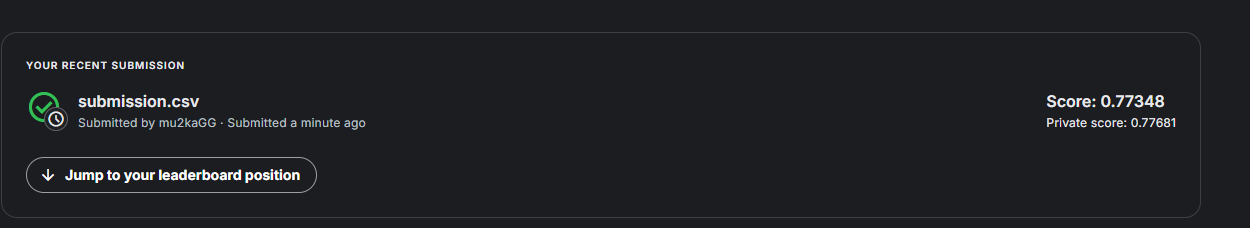